## 🎬IMDB Movies Exploratory Data Analysis 

## Dataset Overview

This dataset contains detailed information about movies, including their title, genre, release year, runtime, ratings, votes, revenue, metascore, directors, and actors.
The dataset helps analyze audience preferences, movie popularity, critical reception, and financial performance in the film industry.

Unlike traditional movie datasets, this analysis focuses on discovering hidden trends behind audience engagement and commercial success.

## Analysis Goals

The primary goals of this analysis are:

- Study how audience ratings vary across movies
- Understand the relationship between votes and revenue
- Analyze movie runtime trends
- Identify the most dominant genres in the industry
- Explore factors affecting movie popularity and success

### Import Required Libraries

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
import matplotlib.style as style
style.use('ggplot')
plt.style.use('seaborn-v0_8')

### Load the Dataset

In [21]:
df = pd.read_csv("C:\\Users\\abhishek\\Downloads\\IMDB-Movie-Data.csv")

### Dataset Preview

In [8]:
df.head()

,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,157606,138.12,62.0
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,60545,270.32,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,393727,325.02,40.0


## Dataset Size

In [9]:
print("Total Rows :", df.shape[0])
print("Total Columns :", df.shape[1])

Total Rows : 1000
Total Columns : 12


## Dataset Information

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Rank                1000 non-null   int64  
 1   Title               1000 non-null   object 
 2   Genre               1000 non-null   object 
 3   Description         1000 non-null   object 
 4   Director            1000 non-null   object 
 5   Actors              1000 non-null   object 
 6   Year                1000 non-null   int64  
 7   Runtime (Minutes)   1000 non-null   int64  
 8   Rating              1000 non-null   float64
 9   Votes               1000 non-null   int64  
 10  Revenue (Millions)  872 non-null    float64
 11  Metascore           936 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 93.9+ KB


## Missing Values Check

In [11]:
df.isnull().sum()

Rank                    0
Title                   0
Genre                   0
Description             0
Director                0
Actors                  0
Year                    0
Runtime (Minutes)       0
Rating                  0
Votes                   0
Revenue (Millions)    128
Metascore              64
dtype: int64

## Statistical Overview

In [12]:
df.describe()

,Rank,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,872.000000,936.000000
mean,500.500000,2012.783000,113.172000,6.723200,1.698083e+05,82.956376,58.985043
std,288.819436,3.205962,18.810908,0.945429,1.887626e+05,103.253540,17.194757
min,1.000000,2006.000000,66.000000,1.900000,6.100000e+01,0.000000,11.000000
25%,250.750000,2010.000000,100.000000,6.200000,3.630900e+04,13.270000,47.000000
50%,500.500000,2014.000000,111.000000,6.800000,1.107990e+05,47.985000,59.500000
75%,750.250000,2016.000000,123.000000,7.400000,2.399098e+05,113.715000,72.000000
max,1000.000000,2016.000000,191.000000,9.000000,1.791916e+06,936.630000,100.000000


## Audience Rating Distribution

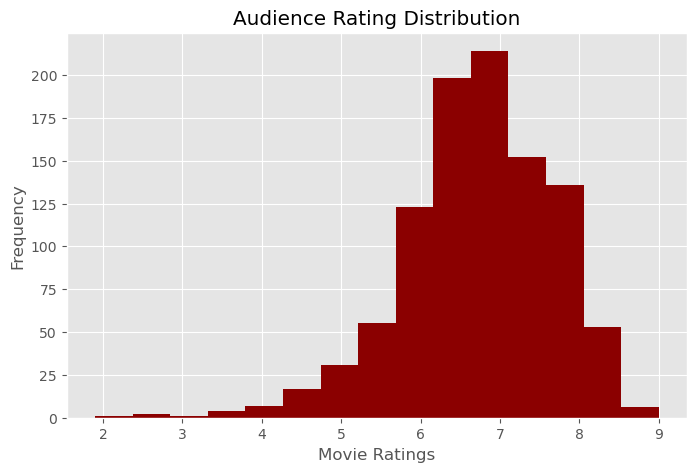

In [13]:
plt.figure(figsize=(8,5))

plt.hist(df['Rating'], bins=15, color='darkred')

plt.title("Audience Rating Distribution")
plt.xlabel("Movie Ratings")
plt.ylabel("Frequency")

plt.show()

### Movie Release Trend

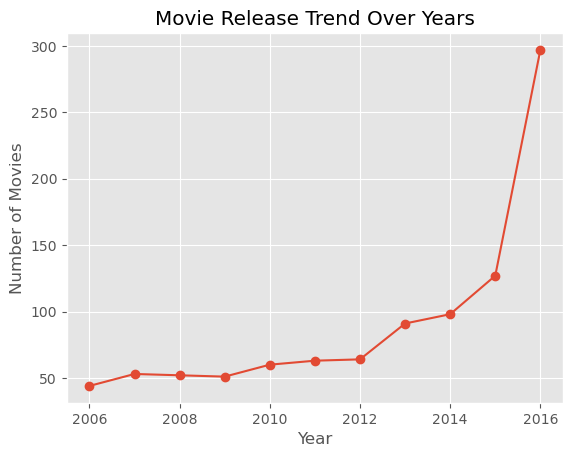

In [14]:
df['Year'].value_counts().sort_index().plot(
    kind='line',
    marker='o'
)

plt.title("Movie Release Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Movies")

plt.show()

### Runtime Pattern Analysis

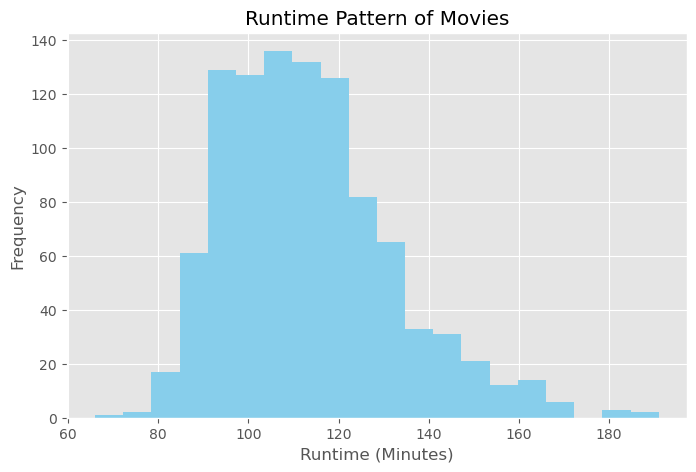

In [15]:
plt.figure(figsize=(8,5))

plt.hist(df['Runtime (Minutes)'], bins=20, color='skyblue')

plt.title("Runtime Pattern of Movies")
plt.xlabel("Runtime (Minutes)")
plt.ylabel("Frequency")

plt.show()

### Display Movies Having Runtime Greater Than 180 Minutes

In [11]:
df[df['Runtime (Minutes)'] >= 180][[
    'Title',
    'Genre',
    'Runtime (Minutes)',
    'Rating',
    'Revenue (Millions)'
]]

,Title,Genre,Runtime (Minutes),Rating,Revenue (Millions)
82,The Wolf of Wall Street,"Biography,Comedy,Crime",180,8.2,116.87
88,The Hateful Eight,"Crime,Drama,Mystery",187,7.8,54.12
311,La vie d'Adèle,"Drama,Romance",180,7.8,2.20
828,Grindhouse,"Action,Horror,Thriller",191,7.6,25.03
965,Inland Empire,"Drama,Mystery,Thriller",180,7.0,NaN


### Top 10 Longest Movies

In [12]:
long_movies = df.sort_values(
    by='Runtime (Minutes)',
    ascending=False
)[['Title','Runtime (Minutes)']].head(10)

long_movies

,Title,Runtime (Minutes)
828,Grindhouse,191
88,The Hateful Eight,187
965,Inland Empire,180
311,La vie d'Adèle,180
82,The Wolf of Wall Street,180
267,Cloud Atlas,172
430,3 Idiots,170
75,Pirates of the Caribbean: At World's End,169
271,The Hobbit: An Unexpected Journey,169
36,Interstellar,169


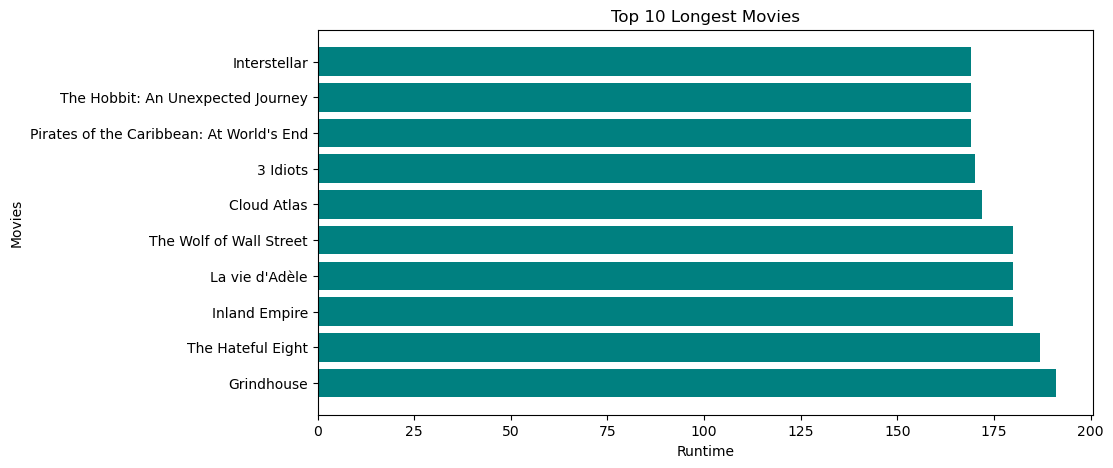

In [39]:
plt.figure(figsize=(10,5))
plt.barh(
    long_movies['Title'],
    long_movies['Runtime (Minutes)'],
    color='teal'
)
plt.title("Top 10 Longest Movies")
plt.xlabel("Runtime")
plt.ylabel("Movies")
plt.show()

### Rating Distribution

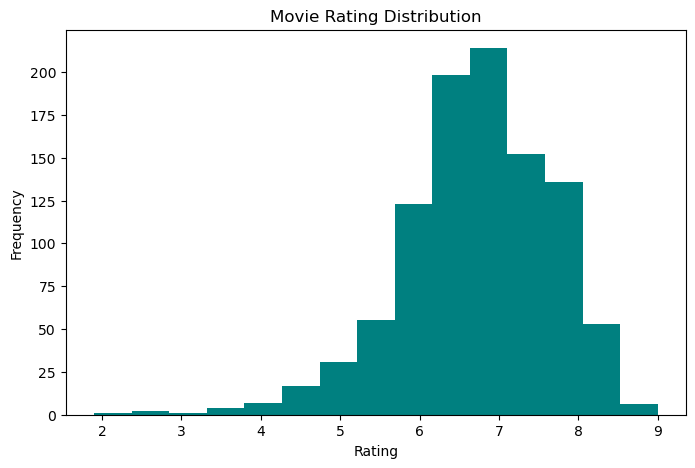

In [40]:
plt.figure(figsize=(8,5))

plt.hist(
    df['Rating'],
    bins=15,
    color='teal'
)

# Using default fonts
plt.title("Movie Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

### Top 10 Most Voted Movies

In [34]:
top_votes = df.sort_values(
    by='Votes',
    ascending=False
).head(10)

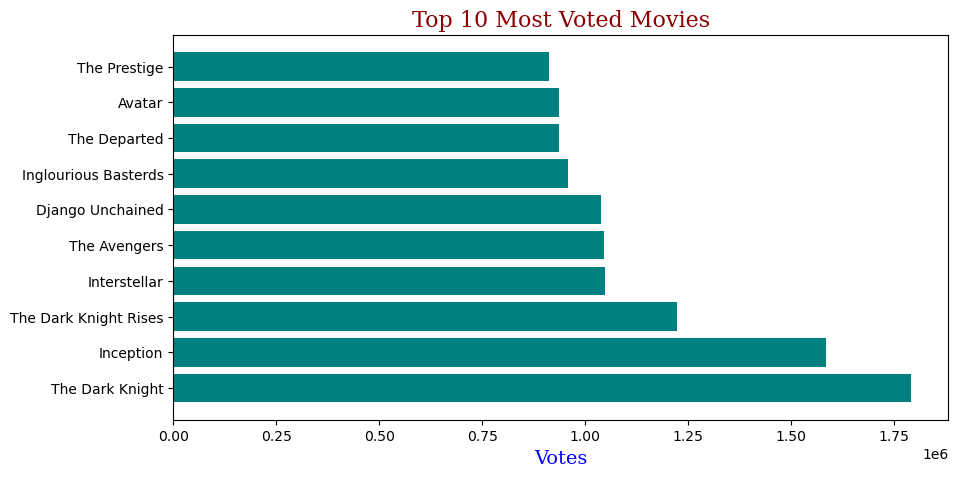

In [36]:
font1 = {'family': 'serif', 'color': 'darkred', 'size': 16}
font2 = {'family': 'serif', 'color': 'blue', 'size': 14}
plt.figure(figsize=(10,5))
plt.barh(
    top_votes['Title'],
    top_votes['Votes'],
    color='teal'
)
plt.title("Top 10 Most Voted Movies", fontdict=font1)
plt.xlabel("Votes", fontdict=font2)
plt.show()

### Runtime vs Metascore Analysis

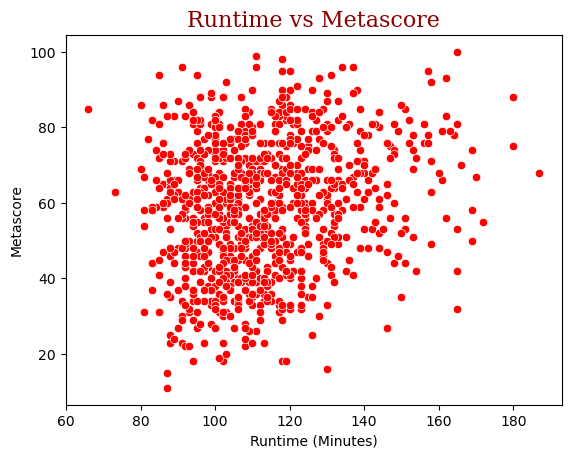

In [42]:
sns.scatterplot(
    x=df['Runtime (Minutes)'],
    y=df['Metascore'],
    color='red'
)

plt.title("Runtime vs Metascore",fontdict=font1)

plt.show()

### Top Directors by Movie Count

top_directors = df['Director'].value_counts().head(10)
top_directors

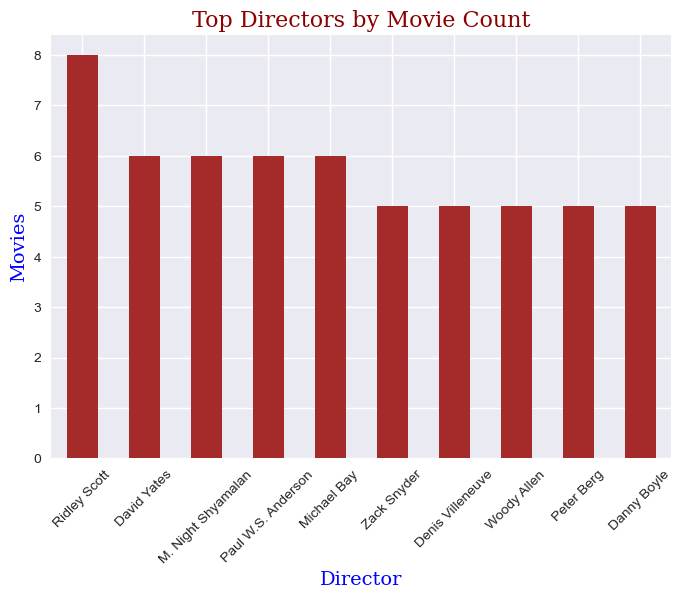

In [88]:
font1 = {'family': 'serif', 'color': 'darkred', 'size': 16}
font2 = {'family': 'serif', 'color': 'blue', 'size': 14}
top_directors = df['Director'].value_counts().head(10)
top_directors.plot(
    kind='bar',
    color='brown'
)
plt.title("Top Directors by Movie Count", fontdict=font1)
plt.xlabel("Director", fontdict=font2)
plt.ylabel("Movies", fontdict=font2)
plt.xticks(rotation=45)
plt.show()

### Genre

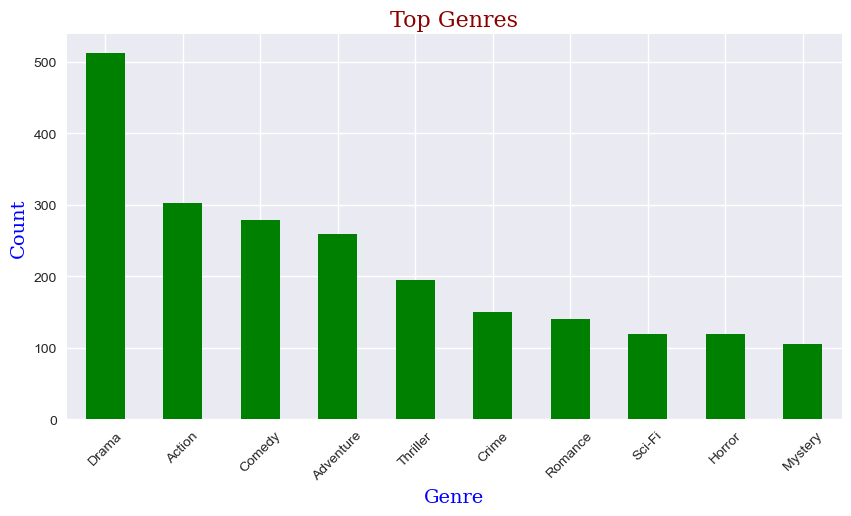

In [58]:
genre_data = df['Genre'].str.split(',').explode()
plt.figure(figsize=(10,5))
genre_data.value_counts().head(10).plot(
    kind='bar',
    color='green'
)
plt.title("Top Genres",fontdict=font1)
plt.xlabel("Genre",fontdict=font2)
plt.ylabel("Count",fontdict=font2)
plt.xticks(rotation=45)
plt.show()

### Genre vs Average Rating

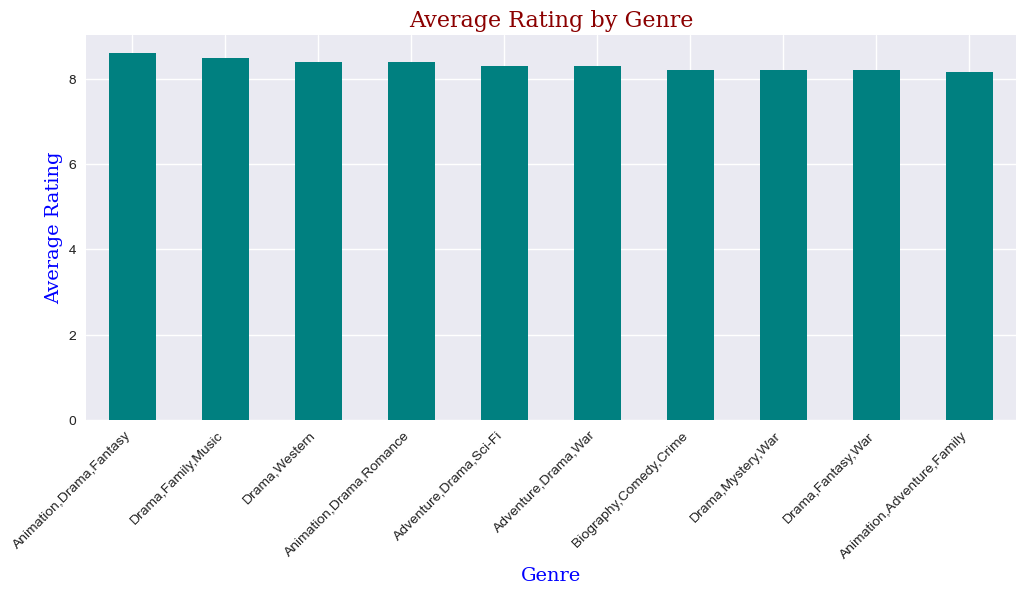

In [62]:
genre_rating = df.groupby('Genre')['Rating'].mean().sort_values(ascending=False)
plt.figure(figsize=(12,5))
genre_rating.head(10).plot(kind='bar',color='TEAL')
plt.title("Average Rating by Genre",fontdict = font_title)
plt.xlabel("Genre",fontdict=font_labels)
plt.ylabel("Average Rating",fontdict=font_labels)
plt.xticks(rotation=45, ha='right')
plt.show()

### Votes Distribution

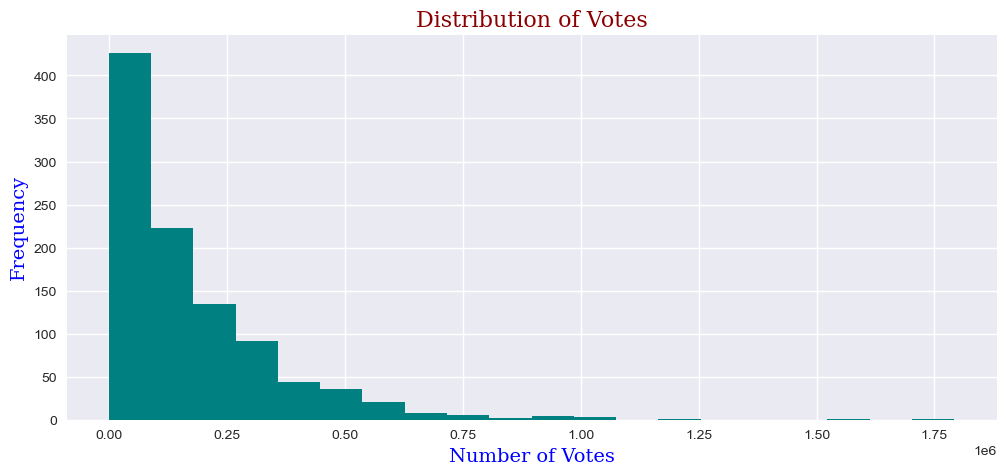

In [84]:
plt.figure(figsize=(12,5))
plt.hist(df['Votes'], bins=20,color='teal')
plt.title("Distribution of Votes",fontdict=font_title)
plt.xlabel("Number of Votes",fontdict=font_labels)
plt.ylabel("Frequency",fontdict=font_labels)
plt.show()


### Voting Vs Rating

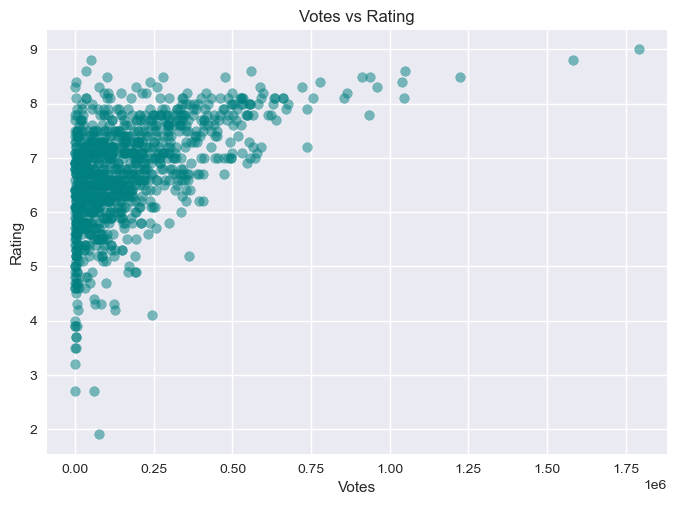

In [83]:
plt.scatter(df['Votes'],df['Rating'],alpha=0.5, color='teal')
plt.title("Votes vs Rating")
plt.xlabel("Votes")
plt.ylabel("Rating")
plt.show()

### Rating vs Revenue Analysis

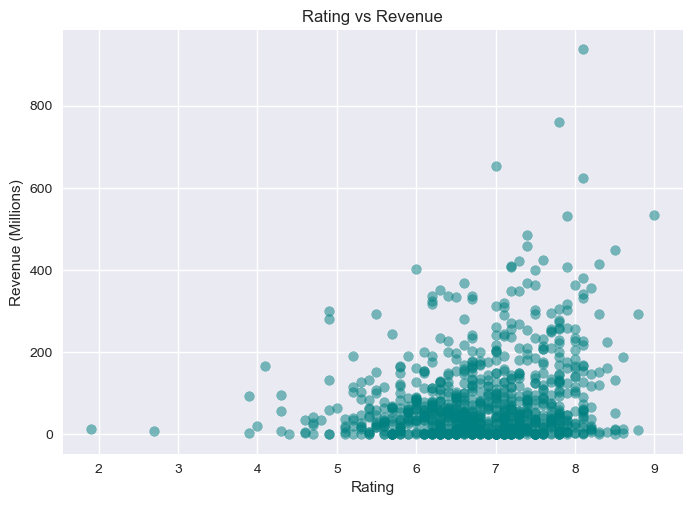

In [81]:
plt.scatter(df['Rating'], df['Revenue (Millions)'], alpha=0.5, color='teal')
plt.title("Rating vs Revenue")
plt.xlabel("Rating")
plt.ylabel("Revenue (Millions)")
plt.show()

### Revenue Distribution by Removing Nulls

In [85]:
df['Revenue (Millions)'].isnull().sum()

np.int64(128)

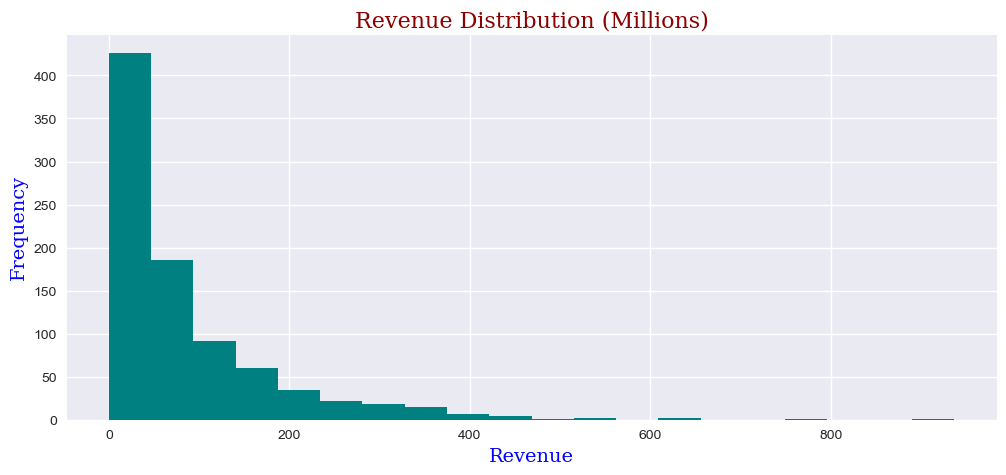

In [87]:
plt.figure(figsize=(12,5))
plt.hist(df['Revenue (Millions)'].dropna(), bins=20,color='teal')
plt.title("Revenue Distribution (Millions)",fontdict=font_title)
plt.xlabel("Revenue",fontdict=font_labels)
plt.ylabel("Frequency",fontdict=font_labels)
plt.show()

### Top 10 Revenue Movies

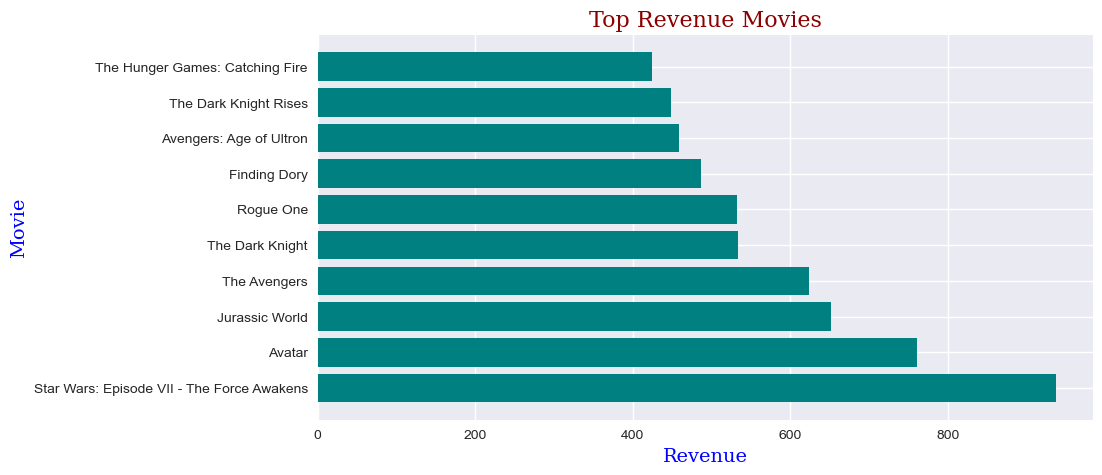

In [93]:
top_movies = df.sort_values(
    by='Revenue (Millions)',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.barh(
    top_movies['Title'],
    top_movies['Revenue (Millions)'],
    color='teal'
)

plt.title("Top Revenue Movies",fontdict=font1)
plt.xlabel("Revenue",fontdict=font2)
plt.ylabel("Movie",fontdict=font2)

plt.show()

### Correlation Heatmap 

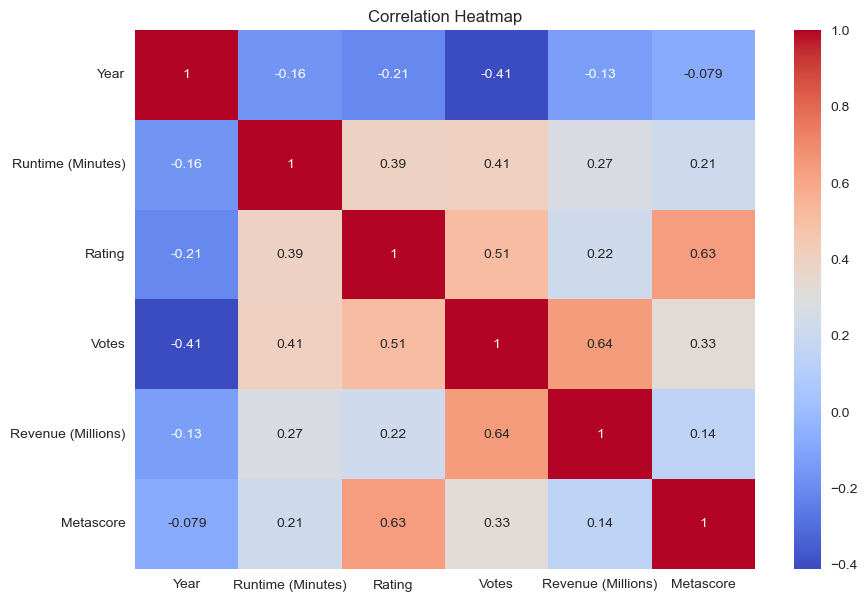

In [90]:
import seaborn as sns

plt.figure(figsize=(10,7))
sns.heatmap(
    df[['Year','Runtime (Minutes)','Rating','Votes','Revenue (Millions)','Metascore']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()